In [21]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker

In [22]:
def pereform(data):
    time=[]
    voltage=[]
    Dt = pd.read_csv(data)
    for t in Dt['t (s)']:
        time.append(t)
    for v in Dt['V (mV)']:
        voltage.append(v)
    return time, voltage

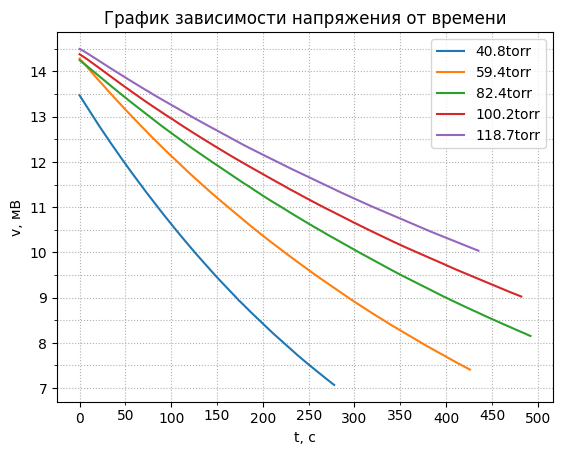

In [23]:
name_list = ['40.8torr', '59.4torr', '82.4torr', '100.2torr', '118.7torr']

for data in name_list:
    t, v = pereform(data + '.csv')
    plt.plot(t, v, label=data)

ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_formatter(ticker.FormatStrFormatter('%g'))
ax.grid(True, which='both', axis='both', linestyle='dotted')
plt.title('График зависимости напряжения от времени')
plt.xlabel("t, с")
plt.ylabel("v, мВ")
plt.show()

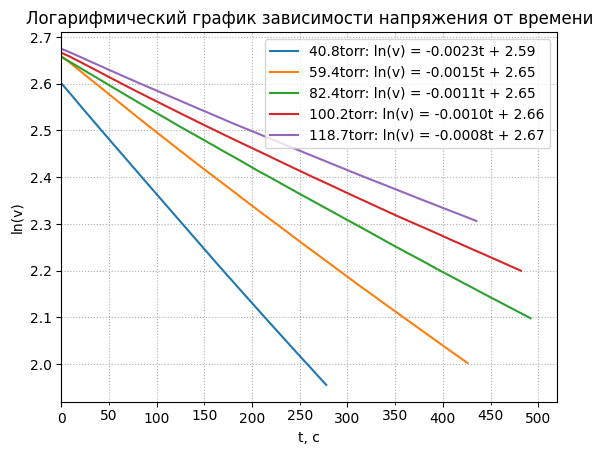

In [24]:
Tau=[]
for data in name_list:
    t, v = pereform(data + '.csv')
    coeffs = np.polyfit(t[50:], np.log(v[50:]), deg=1)
    plt.plot(t, np.log(v), label=f'{data}: ln(v) = {coeffs[0]:.4f}t + {coeffs[1]:.2f}')
    Tau.append(-1/float(coeffs[0]))
    

ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(50))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.xaxis.set_minor_formatter(ticker.FormatStrFormatter('%g'))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(0, 520)
plt.title('Логарифмический график зависимости напряжения от времени')
plt.xlabel("t, с")
plt.ylabel("ln(v)")
plt.show()

In [25]:
print(Tau)

[432.7759290607712, 655.4135279381966, 887.6453909505733, 1046.699382984444, 1194.4811884616838]


In [30]:
P = [1/40.81, 1/59.36, 1/82.36, 1/100.17, 1/118.72]+[0,0,0,0,0,0,0]
D = list(map(lambda x: 6000/x, Tau))+[0,0,0,0,0,0,0]
print(P)
print(D)

[0.024503798088703746, 0.016846361185983826, 0.012141816415735794, 0.009983028850953379, 0.008423180592991913, 0, 0, 0, 0, 0, 0, 0]
[13.863987336406293, 9.154525721913053, 6.759456040857309, 5.732304898176454, 5.023101291136379, 0, 0, 0, 0, 0, 0, 0]


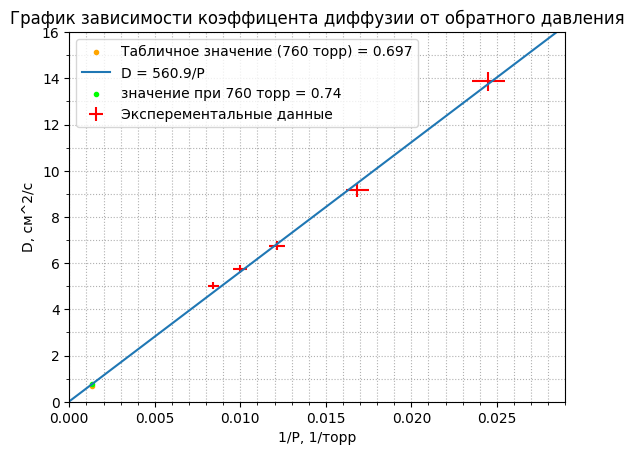

In [40]:
plt.errorbar(P, D, label='Эксперементальные данные',yerr=list(map(lambda x: x*0.03, D)), xerr=list(map(lambda x: x*0.04, P)), ecolor='red', color='none')
plt.scatter(1/760, 0.697, label='Табличное значение (760 торр) = 0.697', marker='.', color='orange')
coeffs = np.polyfit(P, D, deg=1)
poly_func = np.poly1d(coeffs)
x = np.linspace(0, 0.03, 100)
y = poly_func(x)
pupupu = coeffs[0]
plt.plot(x, y, label=f"D = {coeffs[0]:.1f}/P")
plt.scatter(1/760, poly_func(1/760), label=f'значение при 760 торр = {pupupu/760:.2f}', marker='.', color='lime')

ax = plt.gca()
ax.legend()
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.001))  
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
ax.grid(True, which='both', axis='both', linestyle='dotted')
ax.set_xlim(0, 0.029)
ax.set_ylim(0, 16)
plt.title('График зависимости коэффицента диффузии от обратного давления')
plt.xlabel("1/P, 1/торр")
plt.ylabel("D, см^2/с")
plt.show()

In [28]:
print(float(poly_func(1/760)))

0.81204181643224
